In [87]:
import pandas as pd
import numpy as np

metadata = pd.read_excel(rf"C:\Projects\Battery Engineering\Inventory.xlsx", sheet_name="Sheet1")

metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   File Name   7565 non-null   object
 1   Test Type   7565 non-null   object
 2   Cycle ID    7565 non-null   int64 
 3   Battery ID  7565 non-null   object
 4   Capacity    2794 non-null   object
 5   File Path   7565 non-null   object
dtypes: int64(1), object(5)
memory usage: 354.7+ KB


In [88]:
import os
charge=metadata[metadata['Test Type']=='charge']
discharge=metadata[metadata['Test Type']=='discharge']




Bat=charge['Battery ID'].unique()
chg_files=charge[charge['Battery ID']==Bat[0]].reset_index()
dis_files=discharge[discharge['Battery ID']==Bat[0]].reset_index()

#Calucating Min Index of Charging/Discharging Cycle
min_index_charge = charge['Cycle ID'].min()
min_index_discharge = discharge['Cycle ID'].min()

chg =1

if min_index_charge < min_index_discharge:
     dis = 1
else:
     dis = 0

for id,row in chg_files.iterrows():
        summary_dict={}
        summary_dict['Cycle ID']=row['Cycle ID']
        summary_dict['Cycle Pair']=chg
        summary_dict['Battery ID']=Bat[0]
        path=row['File Path'] + "\\" + row['File Name']
        temp_cycle=pd.read_csv(path)
        temp_cycle['Delta Time']=temp_cycle['Time'].diff().shift(-1)
        temp_cycle['Delta_Voltage']=temp_cycle['Voltage_measured'].diff()
        temp_cycle['Charge_Ah']=temp_cycle['Current_measured']*temp_cycle['Delta Time']/3600
        temp_cycle['Energy_Wh']=temp_cycle['Voltage_measured']*temp_cycle['Current_measured']*temp_cycle['Delta Time']/3600
        temp_cycle['dV/dt']=temp_cycle['Delta_Voltage']/temp_cycle['Delta Time']
        temp_cycle=temp_cycle[temp_cycle['Current_measured']>=0.02]
        #Cycle Statistics
        summary_dict['total_ah']=temp_cycle['Charge_Ah'].sum()
        summary_dict['total_wh']=temp_cycle['Energy_Wh'].sum()
        summary_dict['cycle_duration']=max(temp_cycle['Time'])-min(temp_cycle['Time'])
        
        #Voltage Statistics
        summary_dict['max_voltage']=temp_cycle['Voltage_measured'].max()
        summary_dict['min_voltage']=temp_cycle['Voltage_measured'].min()
        summary_dict['average_voltage']=temp_cycle['Voltage_measured'].mean()

        summary_dict['max_dVdt']=temp_cycle['dV/dt'].max()
        summary_dict['min_dVdt']=temp_cycle['dV/dt'].min()
        summary_dict['average_dVdt']=temp_cycle['dV/dt'].mean()
        #temperature Statistics
        summary_dict['max_temp']=temp_cycle['Temperature_measured'].max()
        summary_dict['min_temp']=temp_cycle['Temperature_measured'].min()
        summary_dict['average_temp']=temp_cycle['Temperature_measured'].mean()
        summary_dict['Rise_temp_per_Sec']=(temp_cycle['Temperature_measured'].iloc[-1]-temp_cycle['Temperature_measured'].iloc[0])/summary_dict['cycle_duration']

        #Current Statistics
        summary_dict['max_current']=temp_cycle['Current_measured'].max()
        summary_dict['min_current']=temp_cycle['Current_measured'].min()
        summary_dict['average_current']=temp_cycle['Current_measured'].mean()

        chg += 1

        
        #Appending to CSV File
        Charge_Summary=pd.DataFrame([summary_dict])
        if not os.path.isfile(rf"C:\Projects\Battery Engineering\Summary Files\Charge Summary\Battery_{Bat[0]}_Charge_Summary.csv"):
            Charge_Summary.to_csv(rf"C:\Projects\Battery Engineering\Summary Files\Charge Summary\Battery_{Bat[0]}_Charge_Summary.csv", index=False)
        else:
            Charge_Summary.to_csv(rf"C:\Projects\Battery Engineering\Summary Files\Charge Summary\Battery_{Bat[0]}_Charge_Summary.csv", mode='a', header=False, index=False)
        print(f"Processed Charge Cycle {id + 1} for Battery ID {Bat[0]}")
        #if chg == 6: # Limiting to first 5 cycles for testing
        #    break





        

Processed Charge Cycle 1 for Battery ID B0047
Processed Charge Cycle 2 for Battery ID B0047
Processed Charge Cycle 3 for Battery ID B0047
Processed Charge Cycle 4 for Battery ID B0047
Processed Charge Cycle 5 for Battery ID B0047
Processed Charge Cycle 6 for Battery ID B0047
Processed Charge Cycle 7 for Battery ID B0047
Processed Charge Cycle 8 for Battery ID B0047
Processed Charge Cycle 9 for Battery ID B0047
Processed Charge Cycle 10 for Battery ID B0047
Processed Charge Cycle 11 for Battery ID B0047
Processed Charge Cycle 12 for Battery ID B0047
Processed Charge Cycle 13 for Battery ID B0047
Processed Charge Cycle 14 for Battery ID B0047
Processed Charge Cycle 15 for Battery ID B0047
Processed Charge Cycle 16 for Battery ID B0047
Processed Charge Cycle 17 for Battery ID B0047
Processed Charge Cycle 18 for Battery ID B0047
Processed Charge Cycle 19 for Battery ID B0047
Processed Charge Cycle 20 for Battery ID B0047
Processed Charge Cycle 21 for Battery ID B0047
Processed Charge Cycle

    Cycle ID  Cycle Pair Battery ID  total_ah  total_wh  cycle_duration  \
0          2           1      B0047  1.542413  6.421848       10800.719   
1          5           2      B0047  1.538655  6.381547       10799.500   
2          7           3      B0047  1.522346  6.322247       10805.188   
3          9           4      B0047  1.504613  6.256810       10803.203   
4         11           5      B0047  1.487749  6.190991       10801.578   
5         14           6      B0047  1.468241  6.135367       10802.453   
6         18           7      B0047  1.474341  6.149630       10805.875   
7         21           8      B0047  1.459534  6.078353       10801.750   
8         23           9      B0047  1.437818  5.990443       10799.906   
9         25          10      B0047  1.422333  5.931186       10800.609   
10        27          11      B0047  1.407676  5.876086       10803.594   
11        30          12      B0047  1.390047  5.814765       10801.141   
12        34          13 

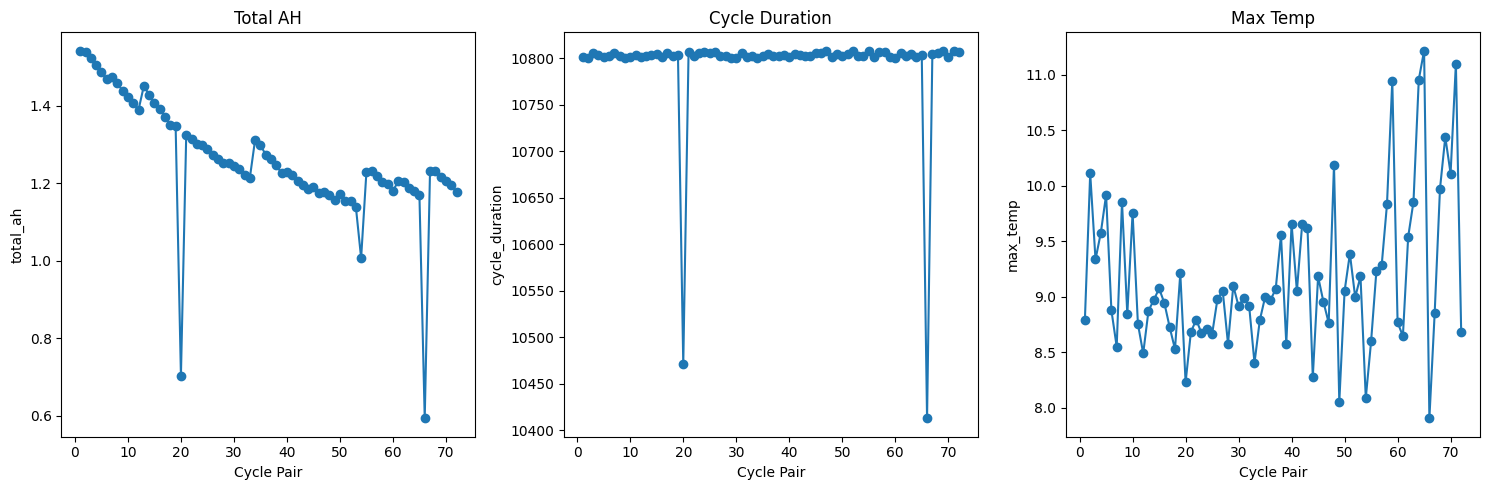

In [ ]:
# Charge Summary Plots

import matplotlib.pyplot as plt

DF=pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Charge Summary\Battery_{Bat[0]}_Charge_Summary.csv")


DF['Cycle Pair'] = DF['Cycle Pair'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # better dimensions for 3 side-by-side

# Plot 1
axes[0].plot(DF['Cycle Pair'], DF['total_ah'], marker='o')
axes[0].set_title("Total AH")
axes[0].set_xlabel("Cycle Pair")
axes[0].set_ylabel("total_ah")

# Plot 2
axes[1].plot(DF['Cycle Pair'], DF['cycle_duration'], marker='o')
axes[1].set_title("Cycle Duration")
axes[1].set_xlabel("Cycle Pair")
axes[1].set_ylabel("cycle_duration")

# Plot 3
axes[2].plot(DF['Cycle Pair'], DF['max_temp'], marker='o')
axes[2].set_title("Max Temp")
axes[2].set_xlabel("Cycle Pair")
axes[2].set_ylabel("max_temp")

plt.tight_layout()
plt.show()

In [91]:
# Discharge Summary
Bat=discharge['Battery ID'].unique()


for id,row in dis_files.iterrows():
        cutoff_voltage=2.5
        summary_dict={}
        summary_dict['Cycle ID']=row['Cycle ID']
        summary_dict['Cycle Pair']=dis
        summary_dict['Battery ID']=Bat[0]
        path=row['File Path'] + "\\" + row['File Name']
        temp_cycle=pd.read_csv(path)
        temp_cycle['Delta Time']=temp_cycle['Time'].diff().shift(-1)
        temp_cycle['Delta_Voltage']=temp_cycle['Voltage_measured'].diff()
        temp_cycle=temp_cycle[(temp_cycle['Current_measured']<-0.05) & (temp_cycle['Voltage_measured']>cutoff_voltage)]

        
        temp_cycle['Discharge_Ah']=temp_cycle['Current_measured']*temp_cycle['Delta Time']/3600
        temp_cycle['Energy_Wh']=temp_cycle['Voltage_measured']*temp_cycle['Current_measured']*temp_cycle['Delta Time']/3600
        temp_cycle['dV/dt']=temp_cycle['Delta_Voltage']/temp_cycle['Delta Time']
        
        #Cycle Statistics
        summary_dict['total_ah']=temp_cycle['Discharge_Ah'].sum()*-1
        summary_dict['total_wh']=temp_cycle['Energy_Wh'].sum()*-1
        summary_dict['cycle_duration']=max(temp_cycle['Time'])-min(temp_cycle['Time'])
        
        #Voltage Statistics
        summary_dict['max_voltage']=temp_cycle['Voltage_measured'].max()
        summary_dict['min_voltage']=temp_cycle['Voltage_measured'].min()
        summary_dict['average_voltage']=temp_cycle['Voltage_measured'].mean()

        summary_dict['max_dVdt']=temp_cycle['dV/dt'].max()
        summary_dict['min_dVdt']=temp_cycle['dV/dt'].min()
        summary_dict['average_dVdt']=temp_cycle['dV/dt'].mean()
        #temperature Statistics
        summary_dict['max_temp']=temp_cycle['Temperature_measured'].max()
        summary_dict['min_temp']=temp_cycle['Temperature_measured'].min()
        summary_dict['average_temp']=temp_cycle['Temperature_measured'].mean()
        summary_dict['Rise_temp_per_Sec']=(temp_cycle['Temperature_measured'].iloc[-1]-temp_cycle['Temperature_measured'].iloc[0])/summary_dict['cycle_duration']

        #Current Statistics
        summary_dict['max_current']=temp_cycle['Current_measured'].max()
        summary_dict['min_current']=temp_cycle['Current_measured'].min()
        summary_dict['average_current']=temp_cycle['Current_measured'].mean()

        dis += 1


        #Appending to CSV File Except File 0 Cycle
        if (dis != 1):
        
            Discharge_Summary=pd.DataFrame([summary_dict])
            if not os.path.isfile(rf"C:\Projects\Battery Engineering\Summary Files\Discharge Summary\Battery_{Bat[0]}_Discharge_Summary.csv"):
                Discharge_Summary.to_csv(rf"C:\Projects\Battery Engineering\Summary Files\Discharge Summary\Battery_{Bat[0]}_Discharge_Summary.csv", index=False)
            else:
                Discharge_Summary.to_csv(rf"C:\Projects\Battery Engineering\Summary Files\Discharge Summary\Battery_{Bat[0]}_Discharge_Summary.csv", mode='a', header=False, index=False)
            
            print(f"Processed Discharge Cycle {id + 1} for Battery ID {Bat[0]}")

        #if dis == 6: # Limiting to first 5 cycles for testing
        #    break

Processed Discharge Cycle 2 for Battery ID B0047
Processed Discharge Cycle 3 for Battery ID B0047
Processed Discharge Cycle 4 for Battery ID B0047
Processed Discharge Cycle 5 for Battery ID B0047
Processed Discharge Cycle 6 for Battery ID B0047
Processed Discharge Cycle 7 for Battery ID B0047
Processed Discharge Cycle 8 for Battery ID B0047
Processed Discharge Cycle 9 for Battery ID B0047
Processed Discharge Cycle 10 for Battery ID B0047
Processed Discharge Cycle 11 for Battery ID B0047
Processed Discharge Cycle 12 for Battery ID B0047
Processed Discharge Cycle 13 for Battery ID B0047
Processed Discharge Cycle 14 for Battery ID B0047
Processed Discharge Cycle 15 for Battery ID B0047
Processed Discharge Cycle 16 for Battery ID B0047
Processed Discharge Cycle 17 for Battery ID B0047
Processed Discharge Cycle 18 for Battery ID B0047
Processed Discharge Cycle 19 for Battery ID B0047
Processed Discharge Cycle 20 for Battery ID B0047
Processed Discharge Cycle 21 for Battery ID B0047
Processe

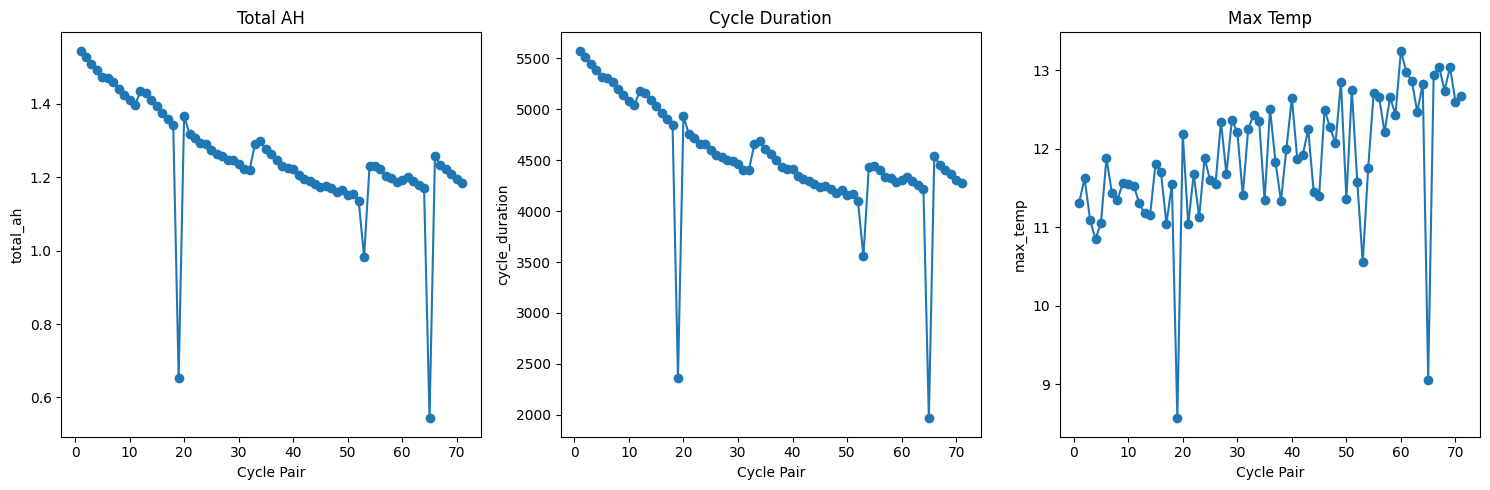

In [92]:
#Discharge Summary Plots

import matplotlib.pyplot as plt


DF=pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Discharge Summary\Battery_{Bat[0]}_Discharge_Summary.csv")

DF['Cycle Pair'] = DF['Cycle Pair'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # better dimensions for 3 side-by-side

# Plot 1
axes[0].plot(DF['Cycle Pair'], DF['total_ah'], marker='o')
axes[0].set_title("Total AH")
axes[0].set_xlabel("Cycle Pair")
axes[0].set_ylabel("total_ah")

# Plot 2
axes[1].plot(DF['Cycle Pair'], DF['cycle_duration'], marker='o')
axes[1].set_title("Cycle Duration")
axes[1].set_xlabel("Cycle Pair")
axes[1].set_ylabel("cycle_duration")

# Plot 3
axes[2].plot(DF['Cycle Pair'], DF['max_temp'], marker='o')
axes[2].set_title("Max Temp")
axes[2].set_xlabel("Cycle Pair")
axes[2].set_ylabel("max_temp")

plt.tight_layout()
plt.show()






In [99]:
#Overall Summary Files

Charge_Summary=pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Charge Summary\Battery_{Bat[0]}_Charge_Summary.csv")
Discharge_Summary=pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Discharge Summary\Battery_{Bat[0]}_Discharge_Summary.csv")

mean_dis_ah=Discharge_Summary['total_ah'].mean()

min_len=min(len(Charge_Summary), len(Discharge_Summary))



Overall_Stats=[]
i = 0
while i < min_len:
    overall_dict={}
    overall_dict['Cycle Pair']=i+1
    overall_dict['Battery ID']=Bat[0]
    overall_dict['Charge_Ah']=Charge_Summary.iloc[i]['total_ah']
    overall_dict['Discharge_Ah']=Discharge_Summary.iloc[i]['total_ah']
    overall_dict['Initial Discharge_Ah']=Discharge_Summary.iloc[0]['total_ah']
    overall_dict['Charge_Wh']=Charge_Summary.iloc[i]['total_wh']
    overall_dict['Discharge_Wh']=Discharge_Summary.iloc[i]['total_wh']
    overall_dict['Charge Duration_Sec']=Charge_Summary.iloc[i]['cycle_duration']
    overall_dict['Discharge Duration_Sec']=Discharge_Summary.iloc[i]['cycle_duration']
    overall_dict['Average_Charge_Voltage']=Charge_Summary.iloc[i]['average_voltage']
    overall_dict['Average_Discharge_Voltage']=Discharge_Summary.iloc[i]['average_voltage']
    overall_dict['Voltage Hysteresis']=overall_dict['Average_Charge_Voltage'] - overall_dict['Average_Discharge_Voltage']
    overall_dict['Max Charge Temperature']=Charge_Summary.iloc[i]['max_temp']
    overall_dict['Max Discharge Temperature']=Discharge_Summary.iloc[i]['max_temp']
    overall_dict['Charge_Tempaerature_Rise_Rate']=Charge_Summary.iloc[i]['Rise_temp_per_Sec']
    overall_dict['Discharge_Tempaerature_Rise_Rate']=Discharge_Summary.iloc[i]['Rise_temp_per_Sec']
    overall_dict['Coulombic_Efficiency_Ah']=(overall_dict['Discharge_Ah']/overall_dict['Charge_Ah'])*100
    overall_dict['Energy_Efficiency_Wh']=(overall_dict['Discharge_Wh']/overall_dict['Charge_Wh'])*100
    overall_dict['SOH']=(overall_dict['Discharge_Ah']/Discharge_Summary.iloc[0]['total_ah'])*100
    if i >=1:
        overall_dict['Capacity_Fade']=(Overall_Stats[-1]['SOH'] - overall_dict['SOH'])
    else:
        overall_dict['Capacity_Fade']=None

    if overall_dict['Charge_Ah']<overall_dict['Discharge_Ah']:
        overall_dict['Cycle Status']='Invalid : Charge Ah less than Discharge Ah'
    elif overall_dict['Discharge_Ah'] < 0.6 * mean_dis_ah:
        overall_dict['Cycle Status']='Invalid : Discharge Ah significantly lower than average'
    else:
        overall_dict['Cycle Status']='Valid'
        
    Overall_Stats.append(overall_dict)
    i += 1

#Analysing Overall Stats


Overall_Stats_DF=pd.DataFrame(Overall_Stats)


Overall_Stats_DF.to_csv(rf"C:\Projects\Battery Engineering\Summary Files\Overall Summary\Battery_{Bat[0]}_Overall_Summary.csv", index=False)


Text(0.5, 1.0, 'State of Health (SOH) over Cycles')

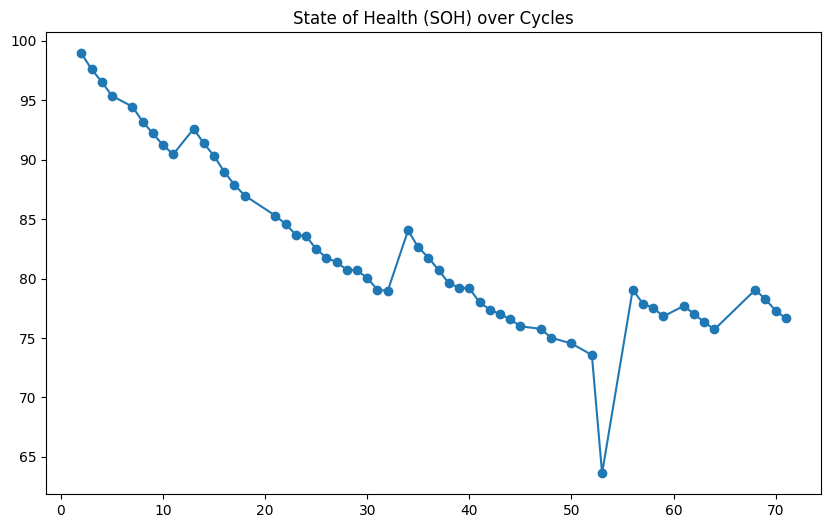

: 

In [ ]:
#Graphs for Overall Summary

plt.figure(figsize=(10,6))
DF=pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Overall Summary\Battery_{Bat[0]}_Overall_Summary.csv")
DF=DF[DF['Cycle Status']=='Valid']
plt.plot(DF['Cycle Pair'], DF['SOH'], marker='o')
plt.title("State of Health (SOH) over Cycles")